In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Initialize path
processed_dir = Path("../data/processed")

# Load datasets
belief_clean = pd.read_parquet(processed_dir / "belief_clean.parquet")
ratings_clean = pd.read_parquet(processed_dir / "ratings_clean.parquet")
add_ratings_clean = pd.read_parquet(processed_dir / "add_ratings_clean.parquet")
recommendations_clean = pd.read_parquet(processed_dir / "recommendations_clean.parquet")
movies_clean = pd.read_parquet(processed_dir / "movies_clean.parquet")

In [2]:
datasets = {
    "Belief": belief_clean,
    "Ratings": ratings_clean,
    "Additional Ratings": add_ratings_clean,
    "Recommendations": recommendations_clean,
    "Movies": movies_clean
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Belief: (3003975, 11)
Ratings: (2004309, 4)
Additional Ratings: (4185688, 4)
Recommendations: (1285352, 4)
Movies: (105071, 3)


In [3]:
for name, df in datasets.items():
    print(f"\n{name}")
    print(df.dtypes)


Belief
user_id                           int32
movie_id                          int32
is_seen                            int8
watch_date               datetime64[us]
user_elicit_rating              float32
user_predict_rating             float32
user_certainty                     int8
tstamp                   datetime64[us]
movie_idx                          int8
source                             int8
system_predict_rating           float32
dtype: object

Ratings
user_id              int32
movie_id             int32
rating             float32
tstamp      datetime64[us]
dtype: object

Additional Ratings
user_id              int32
movie_id             int32
rating             float32
tstamp      datetime64[us]
dtype: object

Recommendations
user_id                     int32
tstamp             datetime64[ms]
movie_id                    int32
predictedRating           float32
dtype: object

Movies
movie_id     int32
title          str
genres      object
dtype: object


In [4]:
# Relationship between system predicted and user predicted ratings
# system_predict_rating vs. user_predict_rating

# Valid user predictions
system_vs_user = belief_clean[
    belief_clean["user_predict_rating"].between(0.5, 5.0)
].copy()

print("System Predicted Rating:")
print(
    system_vs_user["system_predict_rating"]
    .agg(["min", "max", "mean", "std"])
)

print("\nUser Predicted Rating:")
print(
    system_vs_user["user_predict_rating"]
    .agg(["min", "max", "mean", "std"])
)

System Predicted Rating:
min     0.000000
max     5.000000
mean    3.791916
std     0.691688
Name: system_predict_rating, dtype: float32

User Predicted Rating:
min     0.500000
max     5.000000
mean    2.766500
std     1.192892
Name: user_predict_rating, dtype: float32


In [5]:
# Are the two predictions correlated? (via Pearson correlation)
system_user_predict_corr = (
    system_vs_user["system_predict_rating"].corr(system_vs_user["user_predict_rating"])
)

print(f"Correlation between system and user predicted ratings: {system_user_predict_corr:.4f}")

Correlation between system and user predicted ratings: 0.4394


In [6]:
# Does the system typically underestimate or overestimate the user's expectations? (via mean error)
system_vs_user["difference"] = system_vs_user["system_predict_rating"] - system_vs_user["user_predict_rating"]
mean_difference = system_vs_user["difference"].mean()
if mean_difference > 0:
    print(f"The system tends to overestimate the user's expectations by an average of {mean_difference:.2f} points.")
elif mean_difference < 0:
    print(f"The system tends to underestimate the user's expectations by an average of {abs(mean_difference):.2f} points.")
else:
    print("The system's predictions are, on average, accurate.")

The system tends to overestimate the user's expectations by an average of 1.03 points.


In [7]:
# Relationship between user predicted and user elicited (actual) ratings
# user_predict_rating vs. user_elicit_rating

user_prediction_vs_actual = belief_clean[
    (belief_clean["is_seen"] == 1)
    & belief_clean["user_predict_rating"].between(0.5, 5.0)
    & belief_clean["user_elicit_rating"].between(0.5, 5.0)
].copy()

In [8]:
print("User Predicted Rating:")
print(
    user_prediction_vs_actual["user_predict_rating"]
    .agg(["min", "max", "mean", "std"])
)

print("\nUser Elicited Rating:")
print(
    user_prediction_vs_actual["user_elicit_rating"]
    .agg(["min", "max", "mean", "std"])
)

User Predicted Rating:
min     0.500000
max     5.000000
mean    3.396552
std     1.291312
Name: user_predict_rating, dtype: float32

User Elicited Rating:
min     1.000000
max     5.000000
mean    3.517241
std     1.168659
Name: user_elicit_rating, dtype: float32


In [9]:
# Check for correlation between user predicted and elicited ratings
predict_elicit_corr = (
    user_prediction_vs_actual["user_predict_rating"]
    .corr(user_prediction_vs_actual["user_elicit_rating"])
)

print(f"Correlation between user predicted and elicited ratings: {predict_elicit_corr:.4f}")

Correlation between user predicted and elicited ratings: 0.9124


In [10]:
# Relationship between system predicted and user elicited (actual) ratings
# system_predict_rating vs. user_elicit_rating

system_prediction_vs_actual = belief_clean[
    (belief_clean["is_seen"] == 1)
    & belief_clean["user_elicit_rating"].between(0.5, 5.0)
].copy()

In [11]:
system_elicit_corr = (
    system_prediction_vs_actual["system_predict_rating"]
    .corr(system_prediction_vs_actual["user_elicit_rating"])
)

print(f"Correlation between system predicted and user elicited ratings: {system_elicit_corr:.4f}")

Correlation between system predicted and user elicited ratings: 0.4275


| Comparison                           | Correlation | Interpretation              |
| ------------------------------------ | ----------: | --------------------------- |
| System prediction ↔ User expectation |  **0.4394** | Moderate positive alignment |
| User expectation ↔ Actual enjoyment  |  **0.9124** | Very strong alignment       |
| System prediction ↔ Actual enjoyment |  **0.4275** | Moderate positive alignment |

The system predicts ratings approximately 1.03 points higher than users' own expected ratings, on average.

In [12]:
# Rating history overview

rating_datasets = {
    "Ratings": ratings_clean,
    "Additional Ratings": add_ratings_clean
}

for name, df in rating_datasets.items():
    print(name)
    print(f"Rows: {len(df):,}")
    print(f"Unique users: {df['user_id'].nunique():,}")
    print(f"Unique movies: {df['movie_id'].nunique():,}")
    print(f"Unique user-movie pairs: {df[['user_id', 'movie_id']].drop_duplicates().shape[0]:,}")
    print(f"Date range: {df['tstamp'].min()} → {df['tstamp'].max()}")
    print("\n")

Ratings
Rows: 2,004,309
Unique users: 4,418
Unique movies: 85,170
Unique user-movie pairs: 1,723,763
Date range: 1997-09-17 17:53:58 → 2024-05-05 21:45:54


Additional Ratings
Rows: 4,185,688
Unique users: 12,490
Unique movies: 115,619
Unique user-movie pairs: 4,185,688
Date range: 1997-09-15 16:09:20 → 2024-05-05 21:44:02




In [13]:
# Rating distributions
for name, df in rating_datasets.items():
    print(f"\n{name}")
    print(df["rating"].value_counts().sort_index())


Ratings
rating
-1.0    213207
 0.5     41609
 1.0     44277
 1.5     49667
 2.0    111199
 2.5    150319
 3.0    296340
 3.5    329014
 4.0    387070
 4.5    181896
 5.0    163224
Name: count, dtype: int64

Additional Ratings
rating
-1.0    525370
 0.5     69125
 1.0     84342
 1.5     80835
 2.0    212942
 2.5    277762
 3.0    627330
 3.5    691422
 4.0    855064
 4.5    395996
 5.0    365500
Name: count, dtype: int64


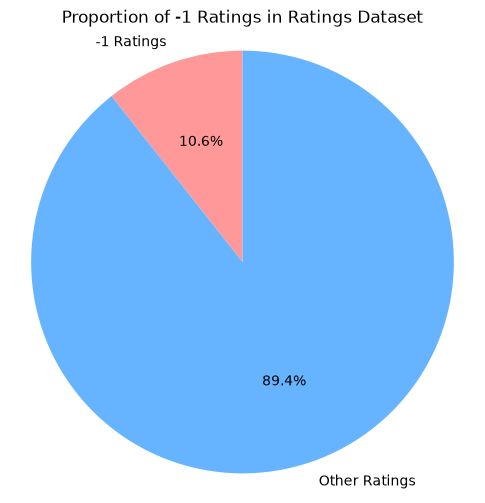

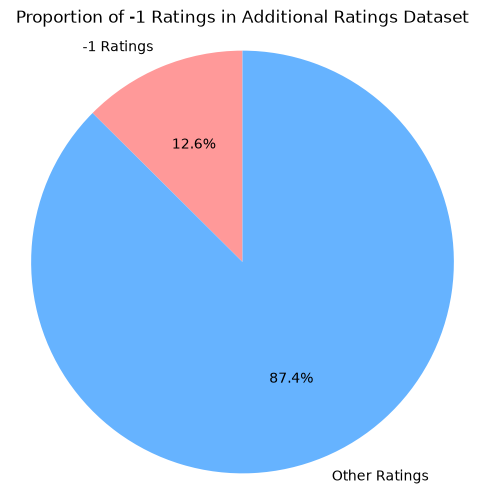

In [14]:
# Proportion of -1 ratings in both datasets via pie chart
for name, df in rating_datasets.items():
    rating_counts = df["rating"].value_counts().sort_index()
    negative_one_count = rating_counts.get(-1, 0)
    total_count = len(df)
    negative_one_proportion = negative_one_count / total_count

    plt.figure(figsize=(6, 6))
    plt.pie(
        [negative_one_proportion, 1 - negative_one_proportion],
        labels=["-1 Ratings", "Other Ratings"],
        autopct="%1.1f%%",
        colors=["#ff9999", "#66b3ff"],
        startangle=90,
    )
    plt.title(f"Proportion of -1 Ratings in {name} Dataset")
    plt.axis("equal")
    plt.show()

In [15]:
# Check for duplicate user-movie pairs and their counts
for name, df in rating_datasets.items():

    pair_counts = (
        df.groupby(["user_id", "movie_id"])
        .size()
    )

    print(f"\n{name}")
    print(f"Unique user-movie pairs: {len(pair_counts):,}")
    print(f"Pairs with multiple events: {(pair_counts > 1).sum():,}")
    print(f"Maximum events for one user-movie pair: {pair_counts.max():,}")


Ratings
Unique user-movie pairs: 1,723,763
Pairs with multiple events: 186,710
Maximum events for one user-movie pair: 101

Additional Ratings
Unique user-movie pairs: 4,185,688
Pairs with multiple events: 0
Maximum events for one user-movie pair: 1


In [16]:
# User activity overview
for name, df in rating_datasets.items():

    user_activity = df.groupby("user_id").size()

    print(f"\n{name}")
    print(user_activity.describe())


Ratings
count     4418.000000
mean       453.668855
std       1152.363495
min          1.000000
25%         27.000000
50%        142.000000
75%        482.750000
max      48106.000000
dtype: float64

Additional Ratings
count     12490.000000
mean        335.123139
std        1598.280052
min           1.000000
25%          15.000000
50%          95.000000
75%         344.000000
max      111534.000000
dtype: float64


In [17]:
# Movie activity overview
for name, df in rating_datasets.items():

    movie_activity = df.groupby("movie_id").size()

    print(f"\n{name}")
    print(movie_activity.describe())


Ratings
count    85170.000000
mean        23.533040
std        116.140955
min          1.000000
25%          1.000000
50%          2.000000
75%          7.000000
max       3510.000000
dtype: float64

Additional Ratings
count    115619.000000
mean         36.202423
std         205.938347
min           1.000000
25%           3.000000
50%           4.000000
75%           8.000000
max        7061.000000
dtype: float64


### Key Finding
* The main ratings table contains repeated user–movie pairs, meaning users can change their ratings over time. The additional ratings table does not.
* -1 ratings make up 10.6% of the main table and 12.6% of the additional table, so they are retained rather than removed.
* Rating activity is highly skewed: the mean is much higher than the median, suggesting a small number of highly active users or movies.
* Ratings are concentrated around 3–4, which may reflect users tending to rate movies they already expect to enjoy.
* The additional ratings table represents a separate user population with no overlap with the main ratings table.

In [18]:
# Recommendation overview

print(f"Rows: {len(recommendations_clean):,}")
print(f"Unique users: {recommendations_clean['user_id'].nunique():,}")
print(f"Unique movies: {recommendations_clean['movie_id'].nunique():,}")
print(f"Unique user-movie pairs: {recommendations_clean[['user_id', 'movie_id']].drop_duplicates().shape[0]:,}")
print(f"Date range: {recommendations_clean['tstamp'].min()} → {recommendations_clean['tstamp'].max()}")

Rows: 1,285,352
Unique users: 4,361
Unique movies: 7,845
Unique user-movie pairs: 110,299
Date range: 2023-03-01 06:10:51 → 2024-04-30 23:59:13


In [19]:
# Check the distribution of predicted ratings
print(recommendations_clean["predictedRating"].agg(["min", "max", "mean", "std"]))

min     0.444623
max     5.000000
mean    4.429983
std     0.417754
Name: predictedRating, dtype: float32


In [20]:
# Check for duplicate user-movie pairs and their counts in recommendations
recommendation_counts = (
    recommendations_clean
    .groupby(["user_id", "movie_id"])
    .size()
)

print(f"Unique user-movie pairs: {len(recommendation_counts):,}")
print(f"Repeated recommendations: {(recommendation_counts > 1).sum():,}")
print(f"Maximum recommendations for one user-movie pair: {recommendation_counts.max():,}")

Unique user-movie pairs: 110,299
Repeated recommendations: 77,516
Maximum recommendations for one user-movie pair: 1,409


### Key Finding
* 1.29M recommendation events correspond to 110K unique user–movie pairs, suggesting that many movies are recommended to the same users repeatedly.
* The average predicted rating is 4.43, suggesting the system generally recommends movies it expects users to like.
* The number of unique user–movie pairs is much smaller than in the ratings datasets, showing that recommendations cover a more selective set of movies.
* The recommendation period is much shorter (2023–2024), which limits the time window available for analyzing whether recommendations lead to later consumption.

In [21]:
# Movies overview

print(f"Rows: {len(movies_clean):,}")
print(f"Unique movie_id: {movies_clean['movie_id'].nunique():,}")

# Inspect the distinct genre tags
all_genres = movies_clean["genres"].explode()
print(f"\nDistinct genre tags: {all_genres.nunique()}")
print(all_genres.value_counts())

Rows: 105,071
Unique movie_id: 105,071

Distinct genre tags: 21
genres
Drama                 40363
Comedy                27140
Thriller              14049
Romance               12034
Action                11454
Documentary           11453
Horror                10461
(no genres listed)     8720
Crime                  8266
Adventure              6358
Sci-Fi                 5693
Animation              5315
Children               5272
Mystery                4711
Fantasy                4523
War                    2679
Western                2017
Musical                1131
Unknown                 442
Film-Noir               366
IMAX                    197
Name: count, dtype: int64


In [22]:
# How many genres does each movie have?
movies_clean["genres"].apply(len).describe()

count    105071.000000
mean          1.738291
std           0.932210
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          10.000000
Name: genres, dtype: float64

### Key Finding

- The movies dataset contains 105,071 movies with 21 genre tags.
- "Unknown" and "(no genres listed)" both mean missing genre data, so they will be combined as "Unknown".
- Most movies have only 1–2 genres (median 1, mean 1.74). Therefore, using the first listed genre as the primary genre is reasonable for most movies.